<a href="https://colab.research.google.com/github/EsmeBarker/Collab/blob/main/EsmeBarkU7Proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install bambi

In [4]:
import pandas as pd
import bambi as bmb
import arviz as az
import pymc as pm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import graphviz as gd

This dataset looks at octopus beaks. It includes the total weight of the beak, the size of the upper and lower beak, and the length of the lateral wall.

In [5]:
octo=pd.read_csv("http://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/octopusbeakweight_nlin.csv")
octo

,totWt,upBeak,loBeak,latWall
0,91,78,78,74
1,532,125,120,131
2,537,101,92,138
3,605,85,107,135
4,647,130,101,155
5,708,139,167,165
6,724,114,143,147
7,900,105,108,127
8,925,129,160,221
9,1074,159,177,168


This pairplot shows reasonably strong linear correlations between all of the variables, with more variation at extremes likely due to the dataset being very small.

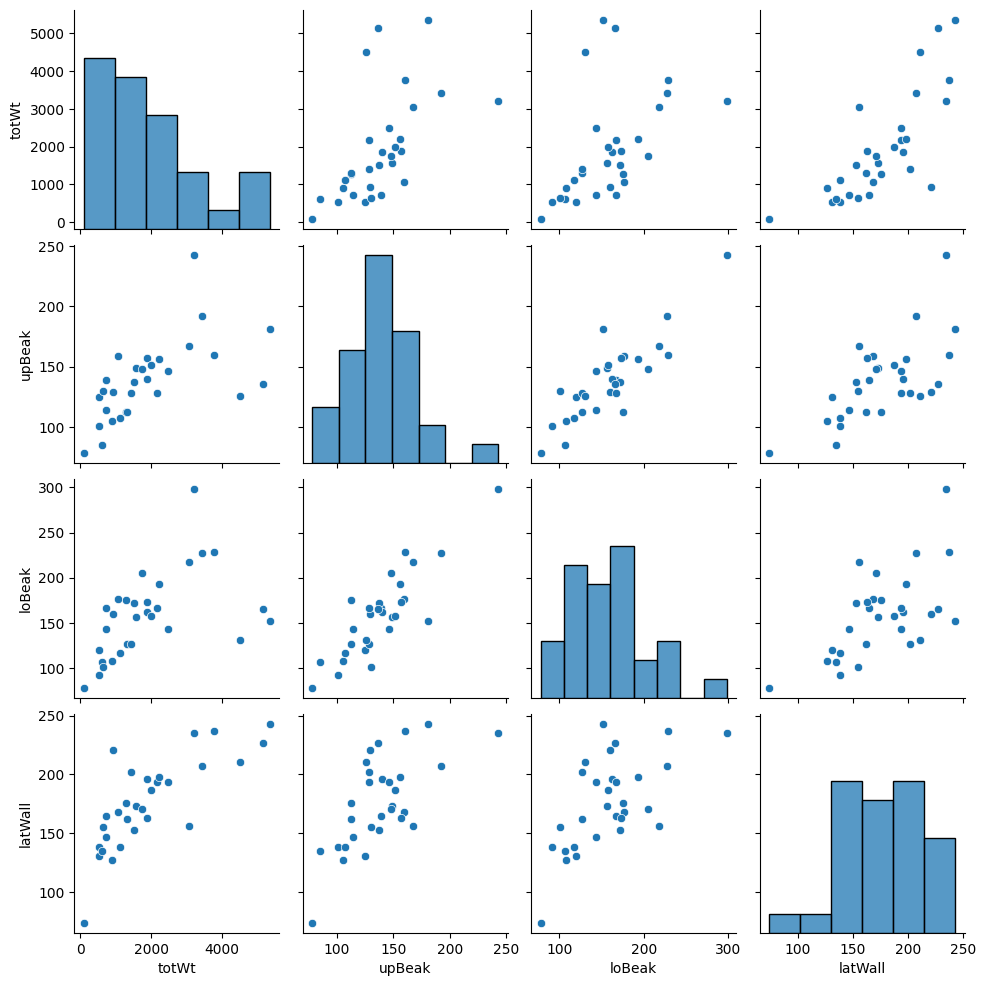

In [6]:
sns.pairplot(octo)

I created a simple casual diagram showing how the variables relate to each other. I decided that I would focus on trying to guess total weight based on the other three variables.

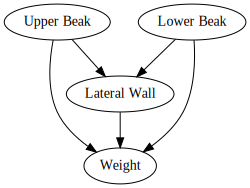

In [7]:
cd=gd.Digraph(comment='octopuses')
cd.node('W', 'Weight')
cd.node('UB', 'Upper Beak')
cd.node('LB', 'Lower Beak')
cd.node('LW', 'Lateral Wall')
cd.edges([('UB', 'LW'),('LB', 'LW'), ('UB', 'W'), ('LB','W'),('LW', 'W')])
cd

My first model was very simple. I had to scale the data because the model basically wasn't working at all otherwise. It's a simple model based off the casual diagram, just using the three variables.

In [ ]:
octo_scaled=octo.copy()
octo_scaled["log_totWt"] = np.log(octo_scaled["totWt"])

model_log = bmb.Model(
    "log_totWt ~ upBeak + loBeak + latWall",
    octo_scaled
)
idata_log = model_log.fit(idata_kwargs={"log_likelihood": True})

The graph this created looks pretty good. The line clearly isn't following the data points super well, but there also just aren't very many.

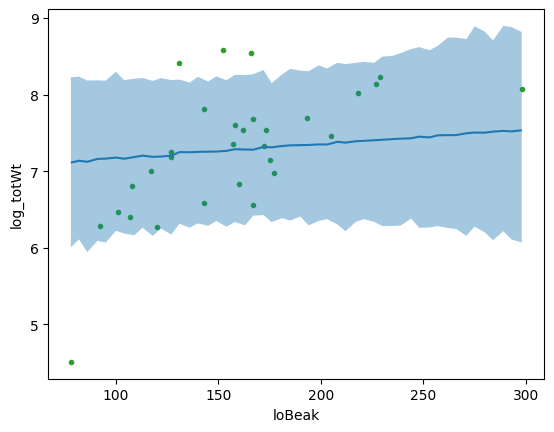

In [27]:
bmb.interpret.plot_predictions(
    model_log,
    idata_log,
    conditional="loBeak",
    pps=True
)

plt.plot(
    octo_scaled.loBeak,
    np.log(octo_scaled.totWt),
    "C2.",
    zorder=-3
)

For my second model I used a polynomial of degree 2 for all variables. I believed this would work better because the data looked kind of curved to me, increasing a lot early on but ending that increase eventually.

In [ ]:
model_poly = bmb.Model(
    "log_totWt ~ poly(upBeak, 2) + poly(loBeak, 2) + poly(latWall, 2)",
    octo_scaled
)
idata_poly = model_poly.fit(idata_kwargs={"log_likelihood": True})

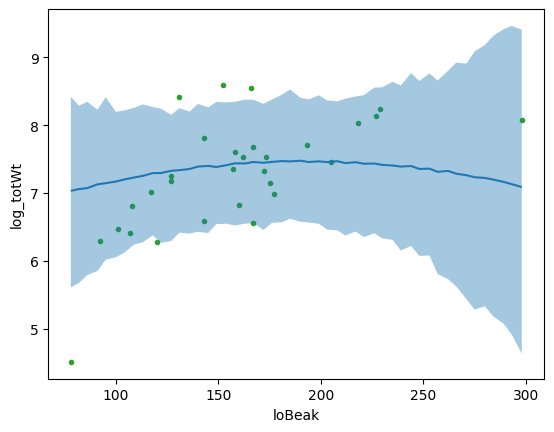

In [32]:
bmb.interpret.plot_predictions(
    model_poly,
    idata_poly,
    conditional="loBeak",
    pps=True
)

plt.plot(
    octo_scaled.loBeak,
    np.log(octo_scaled.totWt),
    "C2.",
    zorder=-3
)

A comparison of the elpd_loo values and the scatterplots show that the poly model does perform a little bit better, but not really by much. I continued to alter my polynomial to try to produce better results.

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

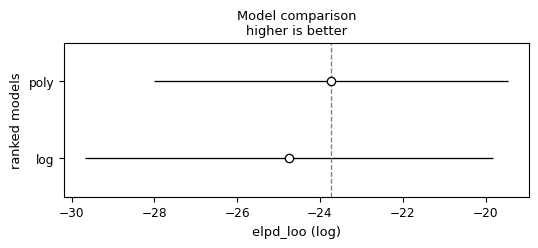

In [57]:
cmp_df = az.compare( {"log":idata_log,"poly":idata_poly
                } )
az.plot_compare(cmp_df)

The next three models were only applying the polynomial to one variable and leaving the other two alone. I tried this with all three variables to see if one would perform best.

In [ ]:
model_polyu = bmb.Model(
    "log_totWt ~ poly(upBeak, 2) + loBeak + latWall",
    octo_scaled
)
idata_polyu = model_polyu.fit(idata_kwargs={"log_likelihood": True})

In [ ]:
model_polyl = bmb.Model(
    "log_totWt ~ poly(loBeak, 2) + upBeak + latWall",
    octo_scaled
)
idata_polyl = model_polyl.fit(idata_kwargs={"log_likelihood": True})

In [ ]:
model_polyw = bmb.Model(
    "log_totWt ~ poly(latWall, 2) + upBeak + loBeak",
    octo_scaled
)
idata_polyw = model_polyw.fit(idata_kwargs={"log_likelihood": True})

A comparison of the elpd_loo's shows that only applying the polynomial to the lower beak performed best, though once again not by much. Still, this is a slightly more significant improvement over the original model, showing that the polynomial strategy was better for modeling this dataset than the linear one.

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

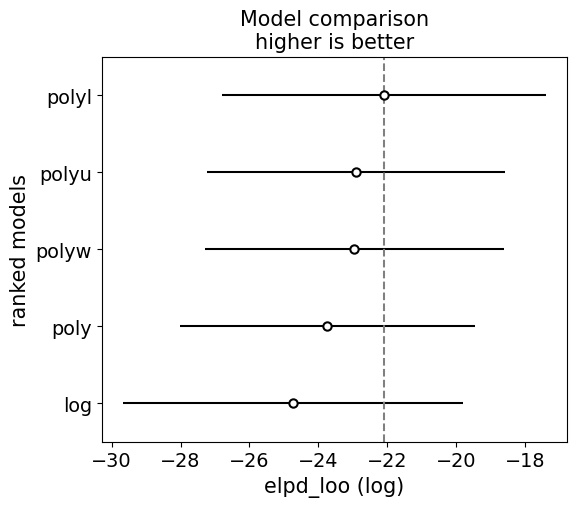

In [56]:
cmp_df = az.compare( {"log":idata_log,"poly":idata_poly, "polyu":idata_polyu, "polyl":idata_polyl, "polyw":idata_polyw
                })
az.plot_compare(cmp_df)

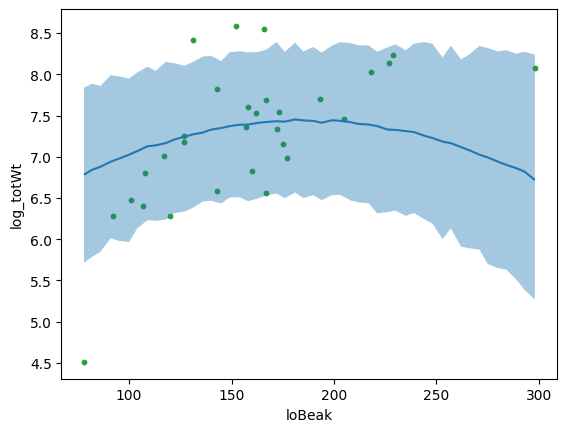

In [60]:
bmb.interpret.plot_predictions(
    model_polyl,
    idata_polyl,
    conditional="loBeak",
    pps=True
)

plt.scatter(octo_scaled.loBeak, octo_scaled.log_totWt, color="C2", s=10, zorder=-3)
plt.show()

Next I tried removing one of each of the other variables to see if simplifying the model could improve it, or if it would function about the same.

In [ ]:
model_polyl1 = bmb.Model(
    "log_totWt ~ poly(loBeak, 2) + upBeak",
    octo_scaled
)
idata_polyl1 = model_polyl1.fit(idata_kwargs={"log_likelihood": True})

In [ ]:
model_polyl2 = bmb.Model(
    "log_totWt ~ poly(loBeak, 2) + latWall",
    octo_scaled
)
idata_polyl2 = model_polyl2.fit(idata_kwargs={"log_likelihood": True})

There was almost no difference when I removed the upper beak data but kept the lateral wall, and if anything it may have been slightly better.

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

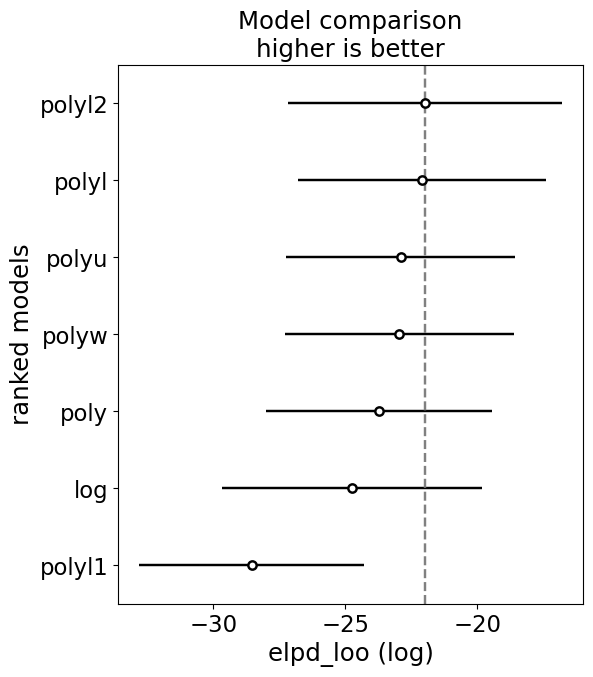

In [55]:
cmp_df = az.compare( {"log":idata_log,"poly":idata_poly, "polyu":idata_polyu, "polyl":idata_polyl, "polyw":idata_polyw, "polyl1":idata_polyl1, "polyl2":idata_polyl2
                }, )
az.plot_compare(cmp_df)

As you can see, this model is actually following the curve of the data pretty well, within reason due to the small number of points.

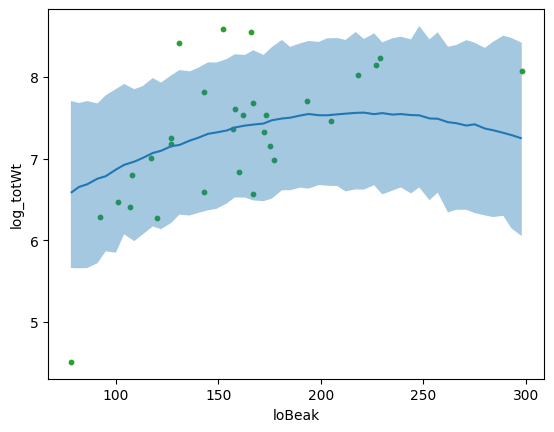

In [66]:
bmb.interpret.plot_predictions(
    model_polyl2,
    idata_polyl2,
    conditional="loBeak",
    pps=True
)

plt.scatter(octo_scaled.loBeak, octo_scaled.log_totWt, color="C2", s=10, zorder=-3)
plt.show()

This other graph comparing it to the laterall wall shows it fitting the data very well.

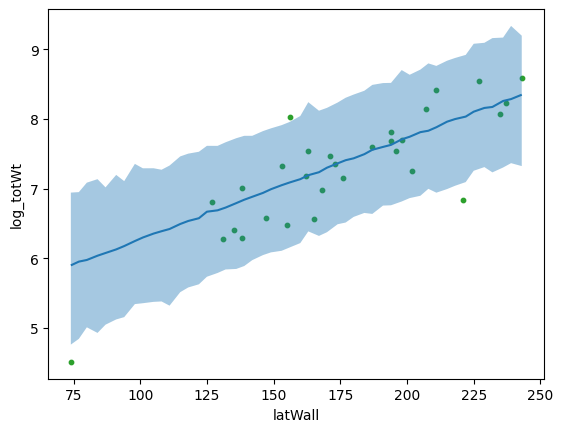

In [67]:
bmb.interpret.plot_predictions(
    model_polyl2,
    idata_polyl2,
    conditional="latWall",
    pps=True
)

plt.scatter(octo_scaled.latWall, octo_scaled.log_totWt, color="C2", s=10, zorder=-3)
plt.show()

In conclusion, I decided that the model using a polynomial for lower beak and ignoring the data from the upper beak worked best. It was simpler than similarly performing models and I could not find one that did better than it. I think a polynomial was a good choice here because it was able to follow the bit of curve the data presented and performed better than a model not using it.